In [1]:
import sys
import importlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import re
import pandas as pd
import numpy as np
from functools import reduce
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact, combine_pvalues
from scipy.stats import chi2_contingency
import pysam
from tqdm import tqdm
from scipy.optimize import curve_fit


plt.rcdefaults()
# mpl.rcParams[''] = 42
# mpl.rcParams['font.size'] = 14

plt.style.use('default')

def theme_classic():
    mpl.rcParams.update({
        'pdf.fonttype': 42,
        'font.size': 12,
        'axes.grid': False,
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'axes.edgecolor': 'black',
        'axes.linewidth': 1.0,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'xtick.direction': 'out',
        'ytick.direction': 'out'
    })

theme_classic()

## plot agg 5' splice site

In [6]:
inpath = '/private/groups/brookslab/gabai/projects/yeastMeth/data/dna/agg/'

In [8]:
def sin_model(x, A, phi, C):
    P = 180  # fixed nucleosome period
    return A * np.sin(2*np.pi*x/P + phi) + C

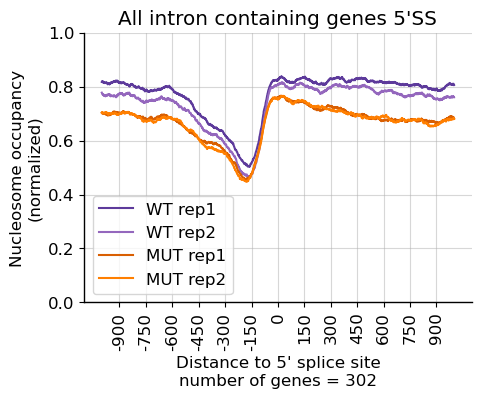

In [22]:
fig, ax1 = plt.subplots(figsize=(5, 3.5))
cmap = ['#5D3A9B', '#9467bd', '#d95f02', '#ff7f00']
ys18_rep1_agg = f'{inpath}260317_ares_v13_all_splicing_ss5_ys18_rep1_aggregate_score.tsv'
ys18_rep2_agg = f'{inpath}260317_ares_v13_all_splicing_ss5_ys18_rep2_aggregate_score.tsv'
ym209_rep1_agg = f'{inpath}260317_ares_v13_all_splicing_ss5_ym209_rep1_aggregate_score.tsv'
ym209_rep2_agg = f'{inpath}260317_ares_v13_all_splicing_ss5_ym209_rep2_aggregate_score.tsv'
allagg = [ys18_rep1_agg, ys18_rep2_agg, ym209_rep1_agg, ym209_rep2_agg]

hw = int(2000/2)
space=150
labels = ['WT rep1', 'WT rep2', 'MUT rep1', 'MUT rep2']
dists = []
amplitudes = []
k = 1
for i in range(len(allagg)):
    with open(allagg[i], 'r') as infile:
        agg_scores = []
        for line in infile:
            line = line.strip().split('\t')
            agg_scores.append(float(line[k]))
        
        # dist between peak to dip
        peak = max(agg_scores[900:1100])
        dip = min(agg_scores[900:1100])
        dist = 0.8 - peak
        agg_scores_norm = [s + dist for s in agg_scores]
        dists.append(peak-dip)

        x = np.arange(-hw, hw+1)
        y = np.array(agg_scores_norm)
        
        # magnitute
        mask = (x > 0) & (x < 800)
        x_fit = x[mask]
        y_fit = y[mask]
        
        popt, _ = curve_fit(sin_model,x_fit,y_fit, p0=[0.1, 0, 0.5])
        
        A_fit = abs(popt[0])
        amplitudes.append(A_fit)

        ax1.plot(np.arange(-hw, hw+1), agg_scores, label = labels[i], color=cmap[i], alpha=1)

x_ticks = np.concatenate((np.flip(np.arange(0, -hw-1, -space)[1:]), np.arange(0, hw+1, space)), axis=0)
ax1.grid(alpha=0.5)
ax1.set_xticks(x_ticks)
ax1.set_xticklabels(x_ticks, rotation='vertical')
ax1.set_xlabel(f"Distance to 5' splice site\nnumber of genes = {302}")
ax1.set_ylabel('Nucleosome occupancy\n(normalized)')
ax1.set_title("All intron containing genes 5'SS")
# ax1.set_xlim(-600, 600)
ax1.set_ylim(0, 1)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.legend()
plt.savefig('../figures/Supp_agg_all_5_splice_site.pdf', bbox_inches='tight')
plt.show()
plt.close()

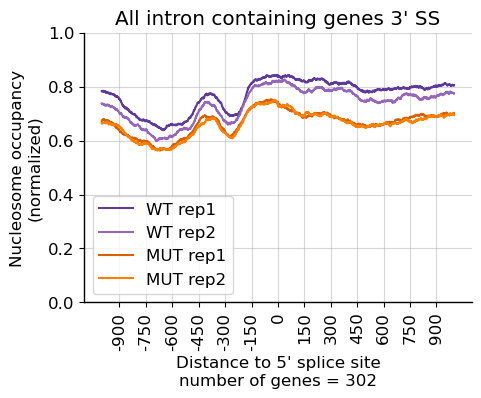

In [23]:
fig, ax1 = plt.subplots(figsize=(5, 3.5))
cmap = ['#5D3A9B', '#9467bd', '#d95f02', '#ff7f00']
ys18_rep1_agg = f'{inpath}260317_ares_v13_all_splicing_ss3_ys18_rep1_aggregate_score.tsv'
ys18_rep2_agg = f'{inpath}260317_ares_v13_all_splicing_ss3_ys18_rep2_aggregate_score.tsv'
ym209_rep1_agg = f'{inpath}260317_ares_v13_all_splicing_ss3_ym209_rep1_aggregate_score.tsv'
ym209_rep2_agg = f'{inpath}260317_ares_v13_all_splicing_ss3_ym209_rep2_aggregate_score.tsv'
allagg = [ys18_rep1_agg, ys18_rep2_agg, ym209_rep1_agg, ym209_rep2_agg]

hw = int(2000/2)
space=150
labels = ['WT rep1', 'WT rep2', 'MUT rep1', 'MUT rep2']
dists = []
amplitudes = []
k = 1
for i in range(len(allagg)):
    with open(allagg[i], 'r') as infile:
        agg_scores = []
        for line in infile:
            line = line.strip().split('\t')
            agg_scores.append(float(line[k]))
        
        # dist between peak to dip
        peak = max(agg_scores[900:1100])
        dip = min(agg_scores[900:1100])
        dist = 0.8 - peak
        agg_scores_norm = [s + dist for s in agg_scores]
        dists.append(peak-dip)

        x = np.arange(-hw, hw+1)
        y = np.array(agg_scores_norm)
        
        # magnitute
        mask = (x > 0) & (x < 800)
        x_fit = x[mask]
        y_fit = y[mask]
        
        popt, _ = curve_fit(sin_model,x_fit,y_fit, p0=[0.1, 0, 0.5])
        
        A_fit = abs(popt[0])
        amplitudes.append(A_fit)

        ax1.plot(np.arange(-hw, hw+1), agg_scores, label = labels[i], color=cmap[i], alpha=1)

x_ticks = np.concatenate((np.flip(np.arange(0, -hw-1, -space)[1:]), np.arange(0, hw+1, space)), axis=0)
ax1.grid(alpha=0.5)
ax1.set_xticks(x_ticks)
ax1.set_xticklabels(x_ticks, rotation='vertical')
ax1.set_xlabel(f"Distance to 5' splice site\nnumber of genes = {302}")
ax1.set_ylabel('Nucleosome occupancy\n(normalized)')
ax1.set_title("All intron containing genes 3' SS")
# ax1.set_xlim(-600, 600)
ax1.set_ylim(0, 1)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.legend()
plt.savefig('../figures/Supp_agg_all_3_splice_site.pdf', bbox_inches='tight')
plt.show()
plt.close()

## DE splicing genes

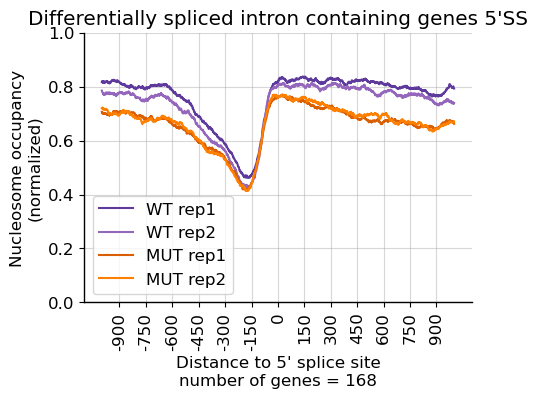

In [24]:
fig, ax1 = plt.subplots(figsize=(5, 3.5))
cmap = ['#5D3A9B', '#9467bd', '#d95f02', '#ff7f00']
ys18_rep1_agg = f'{inpath}260317_ares_v13_de_splicing_ss5_ys18_rep1_aggregate_score.tsv'
ys18_rep2_agg = f'{inpath}260317_ares_v13_de_splicing_ss5_ys18_rep2_aggregate_score.tsv'
ym209_rep1_agg = f'{inpath}260317_ares_v13_de_splicing_ss5_ym209_rep1_aggregate_score.tsv'
ym209_rep2_agg = f'{inpath}260317_ares_v13_de_splicing_ss5_ym209_rep2_aggregate_score.tsv'
allagg = [ys18_rep1_agg, ys18_rep2_agg, ym209_rep1_agg, ym209_rep2_agg]

hw = int(2000/2)
space=150
labels = ['WT rep1', 'WT rep2', 'MUT rep1', 'MUT rep2']
dists = []
amplitudes = []
k = 1
for i in range(len(allagg)):
    with open(allagg[i], 'r') as infile:
        agg_scores = []
        for line in infile:
            line = line.strip().split('\t')
            agg_scores.append(float(line[k]))
        
        # dist between peak to dip
        peak = max(agg_scores[900:1100])
        dip = min(agg_scores[900:1100])
        dist = 0.8 - peak
        agg_scores_norm = [s + dist for s in agg_scores]
        dists.append(peak-dip)

        x = np.arange(-hw, hw+1)
        y = np.array(agg_scores_norm)
        
        # magnitute
        mask = (x > 0) & (x < 800)
        x_fit = x[mask]
        y_fit = y[mask]
        
        popt, _ = curve_fit(sin_model,x_fit,y_fit, p0=[0.1, 0, 0.5])
        
        A_fit = abs(popt[0])
        amplitudes.append(A_fit)

        ax1.plot(np.arange(-hw, hw+1), agg_scores, label = labels[i], color=cmap[i], alpha=1)

x_ticks = np.concatenate((np.flip(np.arange(0, -hw-1, -space)[1:]), np.arange(0, hw+1, space)), axis=0)
ax1.grid(alpha=0.5)
ax1.set_xticks(x_ticks)
ax1.set_xticklabels(x_ticks, rotation='vertical')
ax1.set_xlabel(f"Distance to 5' splice site\nnumber of genes = {168}")
ax1.set_ylabel('Nucleosome occupancy\n(normalized)')
ax1.set_title("Differentially spliced intron containing genes 5'SS")
# ax1.set_xlim(-600, 600)
ax1.set_ylim(0, 1)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.legend()
plt.savefig('../figures/Supp_agg_DE_5_splice_site.pdf', bbox_inches='tight')
plt.show()
plt.close()

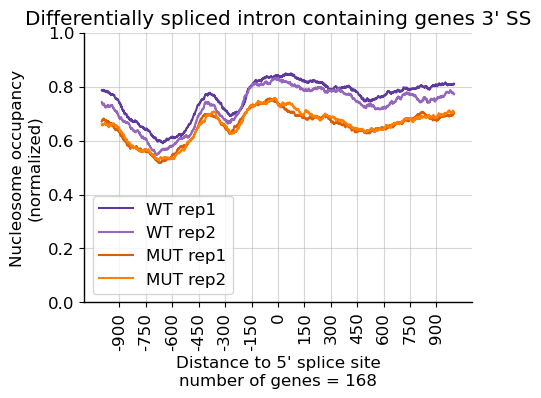

In [25]:
fig, ax1 = plt.subplots(figsize=(5, 3.5))
cmap = ['#5D3A9B', '#9467bd', '#d95f02', '#ff7f00']
ys18_rep1_agg = f'{inpath}260317_ares_v13_de_splicing_ss3_ys18_rep1_aggregate_score.tsv'
ys18_rep2_agg = f'{inpath}260317_ares_v13_de_splicing_ss3_ys18_rep2_aggregate_score.tsv'
ym209_rep1_agg = f'{inpath}260317_ares_v13_de_splicing_ss3_ym209_rep1_aggregate_score.tsv'
ym209_rep2_agg = f'{inpath}260317_ares_v13_de_splicing_ss3_ym209_rep2_aggregate_score.tsv'
allagg = [ys18_rep1_agg, ys18_rep2_agg, ym209_rep1_agg, ym209_rep2_agg]

hw = int(2000/2)
space=150
labels = ['WT rep1', 'WT rep2', 'MUT rep1', 'MUT rep2']
dists = []
amplitudes = []
k = 1
for i in range(len(allagg)):
    with open(allagg[i], 'r') as infile:
        agg_scores = []
        for line in infile:
            line = line.strip().split('\t')
            agg_scores.append(float(line[k]))
        
        # dist between peak to dip
        peak = max(agg_scores[900:1100])
        dip = min(agg_scores[900:1100])
        dist = 0.8 - peak
        agg_scores_norm = [s + dist for s in agg_scores]
        dists.append(peak-dip)

        x = np.arange(-hw, hw+1)
        y = np.array(agg_scores_norm)
        
        # magnitute
        mask = (x > 0) & (x < 800)
        x_fit = x[mask]
        y_fit = y[mask]
        
        popt, _ = curve_fit(sin_model,x_fit,y_fit, p0=[0.1, 0, 0.5])
        
        A_fit = abs(popt[0])
        amplitudes.append(A_fit)

        ax1.plot(np.arange(-hw, hw+1), agg_scores, label = labels[i], color=cmap[i], alpha=1)

x_ticks = np.concatenate((np.flip(np.arange(0, -hw-1, -space)[1:]), np.arange(0, hw+1, space)), axis=0)
ax1.grid(alpha=0.5)
ax1.set_xticks(x_ticks)
ax1.set_xticklabels(x_ticks, rotation='vertical')
ax1.set_xlabel(f"Distance to 5' splice site\nnumber of genes = {168}")
ax1.set_ylabel('Nucleosome occupancy\n(normalized)')
ax1.set_title("Differentially spliced intron containing genes 3' SS")
# ax1.set_xlim(-600, 600)
ax1.set_ylim(0, 1)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.legend()
plt.savefig('../figures/Supp_agg_DE_3_splice_site.pdf', bbox_inches='tight')
plt.show()
plt.close()